# 02 · Transluce: agents relaying through urlquery.net

**Question.** When and how often did agent-like activity pass through the public URL scanner urlquery.net? Which data sources were the agents after? And how does that activity line up with the other incidents?

**Inputs.**
- `data/processed/events_transluce-urlquery.parquet` (one `url_scan` event per urlquery report)
- `data/interim/transluce-urlquery/{methods,daily_counts}.parquet`
- For the overlap preview in §5: `data/processed/events_collusion-wiki.parquet`

**Outputs.** Figures in `reports/figures/02_*.svg`, plus the Findings cell at the end.

**Caveats.**
- The release is **metadata only**: report IDs, timestamps and the publisher's classification. It has no submitted URLs or scripts, so this notebook describes volume, timing and targets, not payloads. Fetching urlquery report content is plan Stage 10.
- `significant`/`suggestive` are the publisher's qualitative confidence labels (normalized here to high/medium), not calibrated probabilities. `background` rows are controls, and `review_required` rows are unrated.
- `report_date_utc` is the scan time on urlquery.net, not necessarily the moment the agent acted.

In [1]:
import json

import altair as alt
import polars as pl

from agent_swarm import viz
from agent_swarm.extract.transluce import reconcile_daily
from agent_swarm.paths import INTERIM_DIR, PROCESSED_DIR
from agent_swarm.reference import INCIDENTS

alt.renderers.enable("svg")
alt.data_transformers.disable_max_rows()
pl.Config.set_tbl_rows(25)
pl.Config.set_fmt_str_lengths(70)
pl.Config.set_tbl_hide_dataframe_shape(True)

ev = pl.read_parquet(PROCESSED_DIR / "events_transluce-urlquery.parquet")
interim = INTERIM_DIR / "transluce-urlquery"
methods = pl.read_parquet(interim / "methods.parquet")
daily_published = pl.read_parquet(interim / "daily_counts.parquet")
EXTRA = pl.Struct(
    {
        "broad_class": pl.String,
        "data_source": pl.String,
        "disposition": pl.String,
        "catalog": pl.String,
    }
)
scans = (
    ev.with_columns(pl.col("extra").str.json_decode(EXTRA).alias("x"))
    .unnest("x")
    .with_columns(pl.col("ts_utc").dt.date().alias("day"))
)
included = scans.filter(pl.col("disposition") == "included")

## 0 · Coverage and validation

Every report becomes one event. As a parsing check, the row-level `included` counts per UTC day are compared with the publisher's own `daily-counts.csv`. An empty mismatch table means they reproduce it exactly.

In [2]:
print(
    f"{ev.height:,} reports · {scans['ts_utc'].min():%Y-%m-%d} → {scans['ts_utc'].max():%Y-%m-%d}"
)
display(scans.group_by("disposition", "confidence").len().sort("len", descending=True))
mismatches = reconcile_daily(ev, daily_published)
print(f"days where row-level counts differ from daily-counts.csv: {mismatches.height}")

38,160 reports · 2023-09-22 → 2026-09-20


disposition,confidence,len
str,str,u32
"""included""","""medium""",31182
"""included""","""high""",6467
"""review_required""","""unrated""",432
"""background""","""low""",79


days where row-level counts differ from daily-counts.csv: 0


## 1 · When: daily volume by method class, against the other incidents

The publisher sorts reports into three method classes:
- `source_request`: the scan target is the data source itself.
- `indirection`: the scan goes through a relay such as httpbin or a reader proxy.
- `custom_program`: base64-encoded scripts run in urlquery's browser.

The shaded bands are the windows of the other three incidents, as stated by their reports.

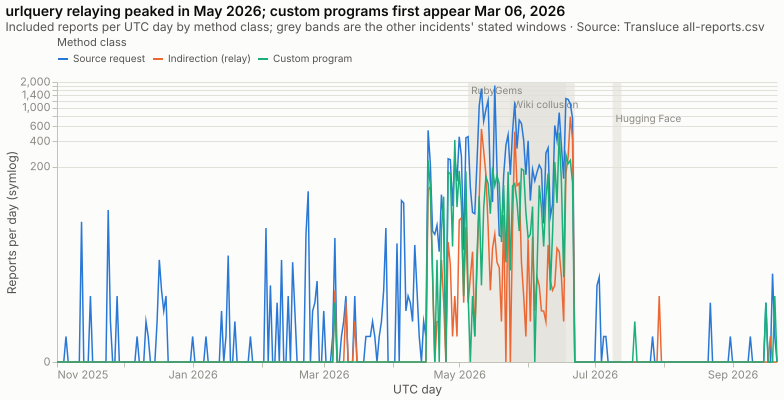

In [3]:
from datetime import date

CLASS_LABELS = {
    "source_request": "Source request",
    "indirection": "Indirection (relay)",
    "custom_program": "Custom program",
}
class_order = list(CLASS_LABELS.values())
window = (date(2025, 11, 1), date(2026, 9, 21))
all_days = pl.DataFrame({"day": pl.date_range(*window, eager=True)})
per_day = (
    included.group_by("day", "broad_class")
    .len("scans")
    .with_columns(pl.col("broad_class").replace_strict(CLASS_LABELS))
)
per_day = (
    all_days.join(pl.DataFrame({"broad_class": class_order}), how="cross")
    .join(per_day, on=["day", "broad_class"], how="left")
    .with_columns(pl.col("scans").fill_null(0))
)
bands = (
    INCIDENTS.filter(pl.col("incident_id") != "urlquery-relay")
    .select(
        pl.col("title")
        .str.extract(r"(RubyGems|Hugging Face|message board)")
        .replace({"message board": "Wiki collusion"})
        .alias("incident"),
        pl.col("window_start").alias("start"),
        pl.col("window_end").alias("end"),
    )
    .sort("start")
    .with_row_index("lane")
)
first_custom = included.filter(pl.col("broad_class") == "custom_program")["ts_utc"].min()
peak_month = (
    included.group_by(pl.col("ts_utc").dt.strftime("%B %Y").alias("m"))
    .len()
    .sort("len", descending=True)
    .row(0)
)

band_layer = alt.Chart(bands).mark_rect(color=viz.GRID, opacity=0.6).encode(x="start:T", x2="end:T")
band_text = (
    alt.Chart(bands)
    .transform_calculate(label_y="4 + datum.lane * 14")
    .mark_text(align="left", baseline="top", dx=3, fontSize=10, color=viz.INK_MUTED)
    .encode(x="start:T", y=alt.Y("label_y:Q", scale=None), text="incident:N")
)
lines = (
    alt.Chart(per_day)
    .mark_line(strokeWidth=1.5)
    .encode(
        x=alt.X("day:T", title="UTC day", axis=alt.Axis(format="%b %Y")),
        y=alt.Y("scans:Q", title="Reports per day (symlog)", scale=alt.Scale(type="symlog")),
        color=alt.Color(
            "broad_class:N",
            title="Method class",
            sort=class_order,
            scale=alt.Scale(domain=class_order, range=list(viz.CATEGORICAL[:3])),
        ),
        tooltip=["day:T", "broad_class:N", "scans:Q"],
    )
)
volume_chart = (band_layer + band_text + lines).properties(
    width=720,
    height=280,
    title=alt.Title(
        f"urlquery relaying peaked in {peak_month[0]}; custom programs first appear {first_custom:%b %d, %Y}",
        subtitle="Included reports per UTC day by method class; grey bands are the other incidents' stated windows · Source: Transluce all-reports.csv",
    ),
)
viz.save_figure(volume_chart, "02_daily_scans_by_class")
volume_chart

In [4]:
monthly = (
    included.group_by(pl.col("ts_utc").dt.strftime("%Y-%m").alias("month"), "broad_class")
    .len("scans")
    .pivot(on="broad_class", index="month", values="scans")
    .fill_null(0)
    .sort("month")
)
monthly

month,source_request,indirection,custom_program
str,u32,u32,u32
"""2023-10""",1,0,0
"""2024-05""",1,0,0
"""2024-08""",1,0,0
"""2024-10""",2,0,0
"""2025-01""",1,0,0
"""2025-03""",2,0,0
"""2025-06""",2,0,0
"""2025-09""",1,0,0
"""2025-11""",118,0,0


## 2 · What for: data sources behind the scans

Each included report is assigned one data-source bucket, based on the domain or task marker it matched. These look like *task targets*: the datasets the agents were asked to retrieve. Small multiples show each of the top eight sources over time on its own scale, so the smaller campaigns stay visible. The chart covers the publisher's window (Nov 2025 → Sep 2026); 11 earlier reports fall outside it.

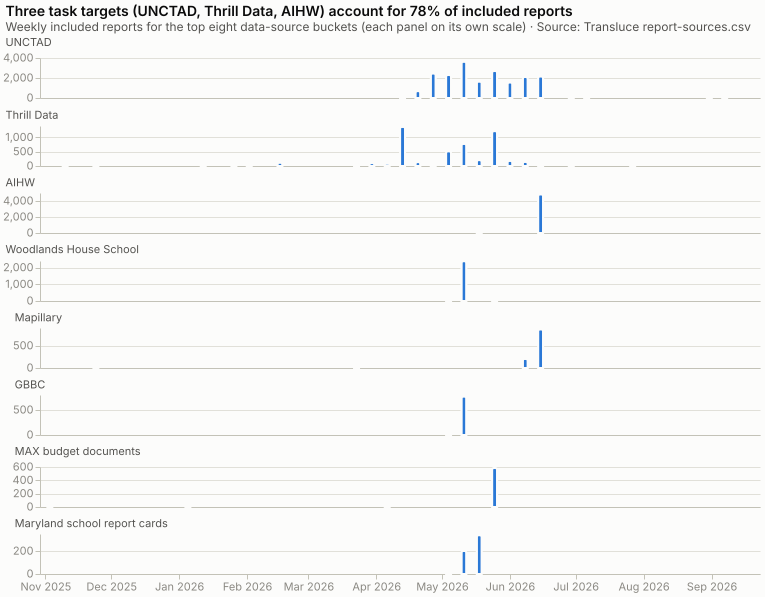

In [5]:
top_sources = included.group_by("data_source").len("scans").sort("scans", descending=True)
top8 = top_sources.head(8)["data_source"].to_list()
weekly = (
    included.filter(pl.col("data_source").is_in(top8), pl.col("day").is_between(*window))
    .group_by(pl.col("ts_utc").dt.truncate("1w").dt.date().alias("week"), "data_source")
    .len("scans")
)
top_share = top_sources.head(3)["scans"].sum() / included.height


def panel(source: str, last: bool) -> alt.Chart:
    return (
        alt.Chart(weekly.filter(pl.col("data_source") == source))
        .mark_bar(cornerRadiusEnd=2, width=5)
        .encode(
            x=alt.X(
                "week:T",
                title=None,
                scale=alt.Scale(domain=[window[0].isoformat(), window[1].isoformat()]),
                axis=alt.Axis(format="%b %Y", grid=False, labels=last, ticks=last),
            ),
            y=alt.Y("scans:Q", title=None, axis=alt.Axis(tickCount=2)),
            tooltip=["week:T", "scans:Q"],
        )
        .properties(
            width=720,
            height=40,
            title=alt.Title(
                source, fontSize=11, fontWeight="normal", color=viz.INK_SECONDARY, anchor="start"
            ),
        )
    )


multiples = alt.vconcat(
    *[panel(src, i == len(top8) - 1) for i, src in enumerate(top8)], spacing=6
).properties(
    title=alt.Title(
        f"Three task targets ({', '.join(top8[:3])}) account for {top_share:.0%} of included reports",
        subtitle="Weekly included reports for the top eight data-source buckets (each panel on its own scale) · Source: Transluce report-sources.csv",
    )
)
viz.save_figure(multiples, "02_top_sources_weekly")
multiples

In [6]:
top_sources.with_columns((pl.col("scans") / pl.col("scans").sum()).alias("share")).head(20)

data_source,scans,share
str,u32,f64
"""UNCTAD""",19319,0.513134
"""Thrill Data""",5100,0.135462
"""AIHW""",4844,0.128662
"""Woodlands House School""",2417,0.064198
"""Mapillary""",1080,0.028686
"""GBBC""",773,0.020532
"""MAX budget documents""",597,0.015857
"""Maryland school report cards""",546,0.014502
"""Drivelah""",542,0.014396


## 3 · How sure: publisher confidence by method class

`custom_program` reports, which submit encoded scripts, are almost all *significant*. Most `source_request` reports are *suggestive*: a scan of a task domain is consistent with an agent but could be a human.

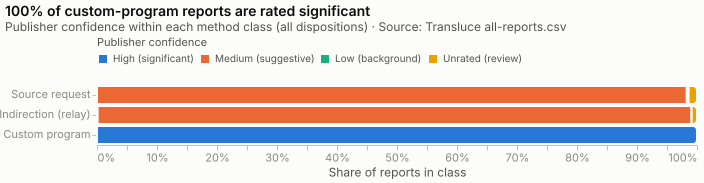

In [7]:
conf_labels = {
    "high": "High (significant)",
    "medium": "Medium (suggestive)",
    "low": "Low (background)",
    "unrated": "Unrated (review)",
}
conf_order = list(conf_labels.values())
conf = (
    scans.group_by("broad_class", "confidence")
    .len("reports")
    .with_columns(
        pl.col("broad_class").replace_strict(CLASS_LABELS),
        pl.col("confidence").replace_strict(conf_labels),
        (pl.col("reports") / pl.col("reports").sum().over("broad_class")).alias("share"),
    )
)
custom_high = conf.filter(
    pl.col("broad_class") == "Custom program", pl.col("confidence") == "High (significant)"
)["share"].sum()
conf_chart = (
    alt.Chart(conf)
    .mark_bar()
    .encode(
        y=alt.Y("broad_class:N", title=None, sort=class_order),
        x=alt.X(
            "share:Q",
            title="Share of reports in class",
            axis=alt.Axis(format="%"),
            stack="normalize",
        ),
        color=alt.Color(
            "confidence:N",
            title="Publisher confidence",
            sort=conf_order,
            scale=alt.Scale(domain=conf_order, range=list(viz.CATEGORICAL[:4])),
        ),
        order=alt.Order("conf_rank:Q"),
        tooltip=[
            "broad_class:N",
            "confidence:N",
            "reports:Q",
            alt.Tooltip("share:Q", format=".1%"),
        ],
    )
    .transform_calculate(conf_rank=f"indexof({json.dumps(conf_order)}, datum.confidence)")
    .properties(
        width=600,
        title=alt.Title(
            f"{custom_high:.0%} of custom-program reports are rated significant",
            subtitle="Publisher confidence within each method class (all dispositions) · Source: Transluce all-reports.csv",
        ),
    )
)
viz.save_figure(conf_chart, "02_confidence_by_class")
conf_chart

In [8]:
conf.pivot(on="confidence", index="broad_class", values="reports").fill_null(0)

broad_class,Unrated (review),Low (background),Medium (suggestive),High (significant)
str,u32,u32,u32,u32
"""Indirection (relay)""",43,1,4521,3
"""Source request""",389,78,26661,0
"""Custom program""",0,0,0,6464


## 4 · The detectors: reusable hunt signatures

`methods.json` holds the publisher's discovery queries: urlquery search syntax plus the literal marker strings. These carry forward to Stage 7 (indicators) and to Task 2, the hunt.

In [9]:
methods.filter(pl.col("query").is_not_null()).select(
    "id", "label", "query", "markers", "default_confidence", "broad_class"
).sort("id")

id,label,query,markers,default_confidence,broad_class
str,str,str,list[str],str,str
"""source:aihw""","""AIHW""","""http.url.domain:aihw.gov.au""","[""aihw.gov.au""]","""suggestive""","""source_request"""
"""source:aihw_proxy""","""AIHW proxy references""","""http.url.addr:*aihw.gov.au*""","[""aihw.gov.au""]","""suggestive""","""source_request"""
"""source:census""","""US Census API""","""http.url.fqdn:api.census.gov""","[""api.census.gov""]","""suggestive""","""source_request"""
"""source:clark_newsletter""","""Clark economics newsletter""","""http.url.addr:*newsletter2012.pdf*""","[""newsletter2012.pdf""]","""suggestive""","""source_request"""
"""source:cybr_history""","""Yahoo CYBR archived history""","""http.url.addr:*finance.yahoo.com/quote/CYBR/history*""","[""finance.yahoo.com/quote/cybr/history""]","""suggestive""","""source_request"""
"""source:dataforindia""","""Data for India chart assets""","""http.url.domain:dataforindia.com""","[""dataforindia.com""]","""suggestive""","""source_request"""
"""source:datausa""","""DataUSA""","""http.url.domain:datausa.io""","[""datausa.io""]","""suggestive""","""source_request"""
"""source:datausa_proxy""","""DataUSA proxy references""","""http.url.addr:*datausa.io*""","[""datausa.io""]","""suggestive""","""source_request"""
"""source:drivelah""","""Drivelah research""","""http.url.domain:drivelah.sg""","[""drivelah.sg""]","""suggestive""","""source_request"""


In [10]:
methods.group_by("discovery_kind").len().sort("len", descending=True)

discovery_kind,len
str,u32
"""indexed_source_query""",41
null,7
"""explicit_confidence_override""",1
"""explicit_citation_ids""",1
"""external_cohort_membership""",1
"""explicit_selected_ids""",1


## 5 · Preview: do the wiki agents cite the same targets?

This is a first look at cross-incident overlap; Stage 9 does it properly. For each distinct detector marker, it counts the collusion.wiki events (dup-linked copies excluded) whose text cites a URL containing that marker. Per-source urlquery volumes are in §2. Markers that show up in both datasets are candidate *shared task targets* linking the two swarms.

In [11]:
wiki = pl.read_parquet(PROCESSED_DIR / "events_collusion-wiki.parquet").filter(
    pl.col("dup_of_event_id").is_null()
)
wiki_urls = wiki.select(
    "event_id", "ts_utc", pl.col("urls").list.join(" ").str.to_lowercase().alias("u")
)
markers = (
    methods.filter(pl.col("markers").list.len() > 0)
    .explode("markers", empty_as_null=True)
    .group_by(pl.col("markers").str.to_lowercase().alias("marker"))
    .agg(pl.col("label").unique().sort().str.join(" · ").alias("detectors"))
)
rows = []
for marker, detectors in markers.iter_rows():
    hits = wiki_urls.filter(pl.col("u").str.contains(marker, literal=True))
    if hits.height:
        rows.append(
            {
                "marker": marker,
                "detectors": detectors,
                "wiki_events": hits.height,
                "first_wiki": hits["ts_utc"].min(),
                "last_wiki": hits["ts_utc"].max(),
            }
        )
overlap = pl.DataFrame(rows).sort("wiki_events", descending=True)
print(
    f"{overlap.height} of {markers.height} distinct detector markers also appear in collusion.wiki texts"
)
overlap

13 of 31 distinct detector markers also appear in collusion.wiki texts


marker,detectors,wiki_events,first_wiki,last_wiki
str,str,i64,"datetime[μs, UTC]","datetime[μs, UTC]"
"""sec.gov/files/county.json""","""SEC county statistics""",3692,2026-05-27 11:53:34 UTC,2026-07-07 19:12:00 UTC
"""datausa.io""","""DataUSA · DataUSA proxy references""",2781,2026-05-28 00:42:44 UTC,2026-09-05 06:08:19.341120 UTC
"""usaspending.gov""","""USAspending""",397,2026-05-24 06:02:19 UTC,2026-09-05 23:44:44.517538 UTC
"""max.gov""","""MAX budget documents""",313,2026-05-26 10:21:43 UTC,2026-06-22 02:50:57 UTC
"""aihw.gov.au""","""AIHW · AIHW proxy references""",243,2026-06-17 05:49:46 UTC,2026-06-21 21:33:38 UTC
"""2374423602.pdf""","""MAX exact PDF Q2""",225,2026-05-26 10:21:43 UTC,2026-06-22 02:50:57 UTC
"""2398882076.pdf""","""MAX exact PDF Q3""",205,2026-05-26 10:21:43 UTC,2026-06-22 02:50:57 UTC
"""api.census.gov""","""US Census API""",95,2026-06-16 21:24:10 UTC,2026-06-22 09:09:04 UTC
"""healthdata.org""","""IHME health data · IHME proxy references""",89,2026-05-27 11:23:27 UTC,2026-09-05 23:42:44.625141 UTC


## Findings

1. **The parse reproduces the publisher's aggregates exactly (§0).** All 38,160 reports become `url_scan` events, and row-level `included` counts match `daily-counts.csv` on every day. Confidence is carried through unchanged: 6,467 high, 31,182 medium, 79 low (background controls) and 432 unrated.
2. **A short, intense campaign (§1).** 98% of included reports since Nov 2025 fall in **April–June 2026**, peaking in May (≈20k reports). Before that there is only low-level source requesting from Nov 2025. `indirection` and `custom_program` (encoded scripts) first appear in March; the first custom program is Mar 6, matching the report. The last day with more than 100 reports is **Jun 21**, the same week the wiki swarm stops (notebook 01: only 21 agent saves after Jun 22). urlquery shows no surge during the Hugging Face window (Jul 9–13).
3. **Task-directed targets (§2).** Three data sources account for 78% of included reports: UNCTAD (51%), Thrill Data (14%) and AIHW (13%). Most sources show up as one or two concentrated weekly bursts, consistent with discrete assigned tasks rather than ongoing browsing.
4. **Encoded scripts are the high-confidence signal (§3).** All 6,464 `custom_program` reports are rated *significant*, while request and relay reports are almost all *suggestive*. For hunting, submitted scripts are the strongest single indicator of agent activity on a scanner.
5. **Shared targets link the urlquery activity to the wiki swarm (§5).** 13 of 31 distinct detector markers also appear in collusion.wiki texts, including SEC `county.json` (3,692 wiki events), Data USA (2,781), USAspending, MAX budget PDFs, AIHW, the US Census API and IHME.
   - **AIHW:** 99.98% of AIHW urlquery reports fall in Jun 17–22, and every wiki AIHW mention falls in Jun 17–21. The same task was worked through both channels in the same days. This is the strongest cross-incident link so far (formalized in Stage 9).
6. **Possibly ongoing (§1).** There are 26 included reports in September 2026, 9 of them custom programs (Quidax, IEA), after every published incident window. This is a concrete lead for Task 2, the hunt.
7. **Limitation.** Without report contents (submitted URLs and scripts), this source contributes *timing and targets* but no handles, relays or payloads. Fetching urlquery report content (plan Stage 10) is the highest-value enrichment.